### Goal
Obatins the linear gain (G) and compare the linear output expected with the real output

#### 1. Setup

In [9]:
# Importing packages
import numpy as np
import pandas as pd

from pa_model.dataset import Dataset
from pa_model.paths import DATA_RAW, DATA_PROCESSED

from pathlib import Path
import matplotlib.pyplot as plt

#### 2. Functions

In [10]:
EPS = 1e-15

def to_decibel(v):
    """complexo -> magnitude em dB"""
    return 20 * np.log10(np.abs(v) + EPS)

In [11]:
# Ploting the AM/AM signal
def plot_AM_AM(x, y, db=True, title="AM/AM Graph"):
    fig, ax = plt.subplots(figsize=(10, 5))
    if db:
        ax.plot(to_decibel(x), to_decibel(y), '.', ms=3, alpha=.3)
        ax.set_xlabel("|x| (dB)"); ax.set_ylabel("|y| (dB)")
    else:
        ax.plot(np.abs(x), np.abs(y), '.', ms=3, alpha=.3)
        ax.set_xlabel("|x|"); ax.set_ylabel("|y|")
    ax.set_title(title); ax.grid(True, alpha=.3)
    plt.show()

#### 3. Loading and Ploting Data

In [ ]:
# Loading Dataset
path_initial_data = f"{DATA_RAW}/dadosIniciais.csv"
path_experiment_data = f"{DATA_PROCESSED}/expData.csv"

if Path(path_experiment_data).exists():
    ds = Dataset.from_csv(path_experiment_data)
else:
    df = pd.read_csv(path_initial_data)
    df = df.loc[df.index.repeat(10)].reset_index(drop=True)
    df = df.sample(frac=1,random_state=42).reset_index(drop=True)
    df.to_csv(path_experiment_data,index=False)
    ds = Dataset.from_csv(path_experiment_data)

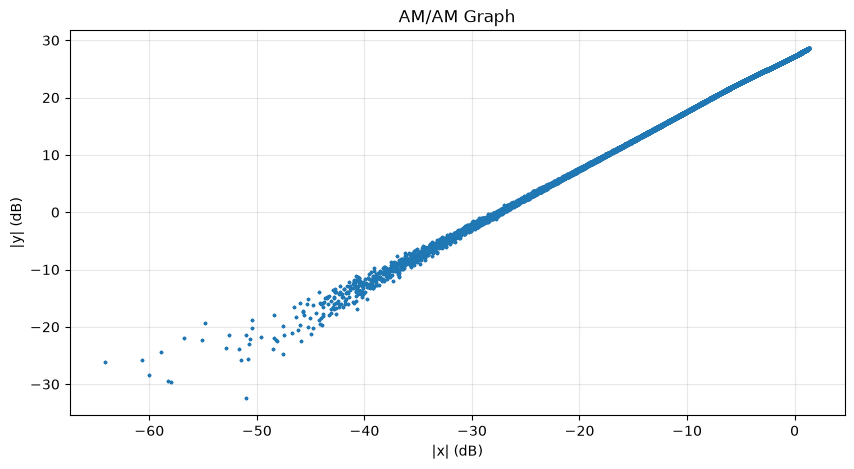

In [ ]:
# Ploting AM/AM
plot_AM_AM(ds.x, ds.y)

In [ ]:
# Filtering Dataset to get only the values with linear relation
x_db = to_decibel(ds.x)
mask = (x_db > -20) & (x_db < 0)
filtered_x, filtered_y = ds.x[mask], ds.y[mask]

In [ ]:
# Ploting Filtered Data
plot_AM_AM(filtered_x,filtered_y)